develop an RNN model to perform sequence prediction where the model learns to predict the next value  in a numerical sequence

1. create a dataset of numerical sequences
2. build in RNN based regression model 
3. train the model using a regression loss function 
4. plot actual vs predicted values.



Using Device: cuda


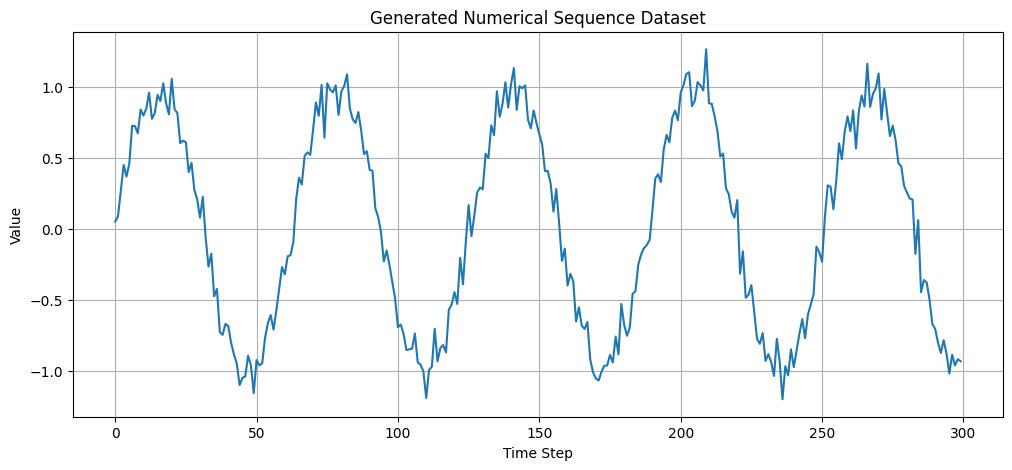


================ MODEL SUMMARY ================

Epoch [10/100] Loss: 0.014854
Epoch [20/100] Loss: 0.013442
Epoch [30/100] Loss: 0.012414
Epoch [40/100] Loss: 0.012760
Epoch [50/100] Loss: 0.012751
Epoch [60/100] Loss: 0.012208
Epoch [70/100] Loss: 0.011498
Epoch [80/100] Loss: 0.013510
Epoch [90/100] Loss: 0.012744
Epoch [100/100] Loss: 0.011414


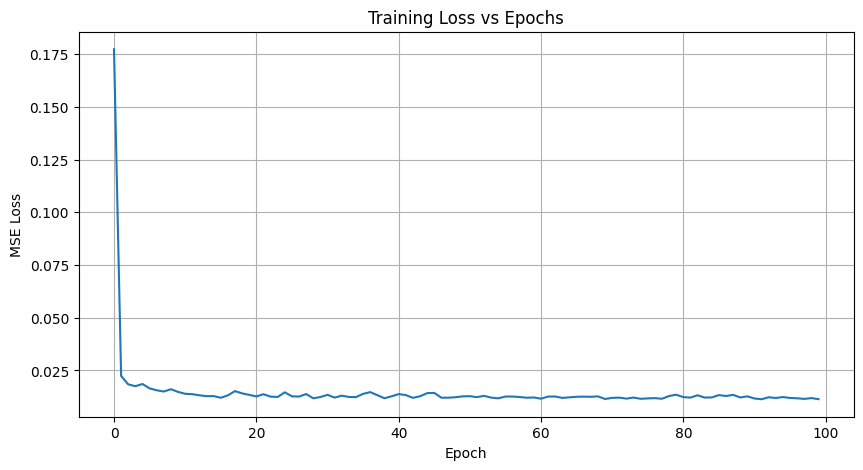

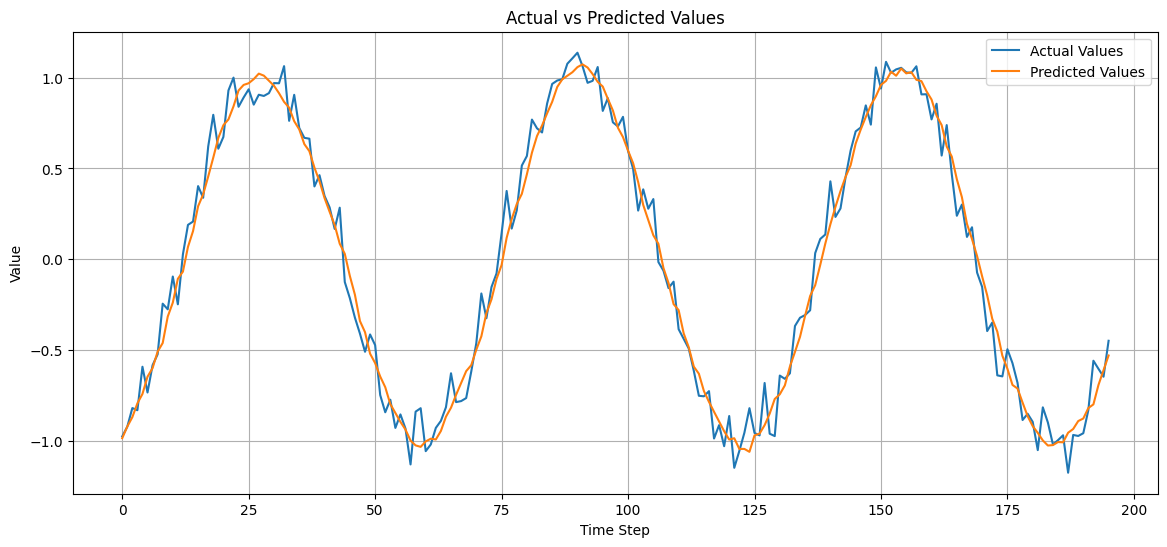

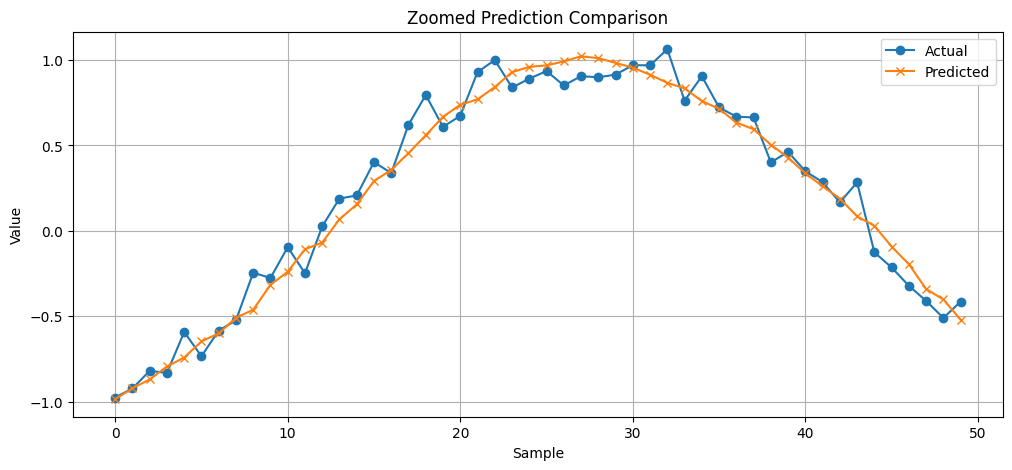


================ SAMPLE PREDICTIONS ================

Actual: -0.9758 | Predicted: -0.9857
Actual: -0.9225 | Predicted: -0.9218
Actual: -0.8197 | Predicted: -0.8699
Actual: -0.8316 | Predicted: -0.7937
Actual: -0.5921 | Predicted: -0.7421
Actual: -0.7340 | Predicted: -0.6470
Actual: -0.5836 | Predicted: -0.5998
Actual: -0.5236 | Predicted: -0.5092
Actual: -0.2448 | Predicted: -0.4616
Actual: -0.2759 | Predicted: -0.3158

Plots saved successfully.


In [3]:
# =========================================================
# RNN Sequence Prediction using PyTorch
# WITH:
# 1. Dataset Visualization
# 2. Model Summary
# 3. Training Loss Plot
# 4. Actual vs Predicted Plot
# 5. GPU Support
# =========================================================

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary

# =========================================================
# DEVICE CONFIGURATION
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# =========================================================
# 1. CREATE DATASET OF NUMERICAL SEQUENCES
# =========================================================

np.random.seed(42)
torch.manual_seed(42)

# Generate sine wave dataset
time_steps = np.linspace(0, 100, 1000)

data = np.sin(time_steps) + 0.1 * np.random.randn(1000)

# =========================================================
# DATASET VISUALIZATION
# =========================================================

plt.figure(figsize=(12, 5))

plt.plot(data[:300])

plt.title("Generated Numerical Sequence Dataset")
plt.xlabel("Time Step")
plt.ylabel("Value")

plt.grid(True)

plt.savefig("dataset_visualization.png", dpi=300)

plt.show()

# =========================================================
# CREATE INPUT SEQUENCES
# =========================================================

SEQ_LENGTH = 20

X = []
y = []

for i in range(len(data) - SEQ_LENGTH):

    X.append(data[i:i + SEQ_LENGTH])

    y.append(data[i + SEQ_LENGTH])

X = np.array(X)
y = np.array(y)

# Reshape for RNN:
# (batch_size, sequence_length, input_size)

X = X.reshape(-1, SEQ_LENGTH, 1)

# =========================================================
# CONVERT TO TENSORS
# =========================================================

X_tensor = torch.tensor(X, dtype=torch.float32)

y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

split_index = int(0.8 * len(X_tensor))

X_train = X_tensor[:split_index]
y_train = y_tensor[:split_index]

X_test = X_tensor[split_index:]
y_test = y_tensor[split_index:]

# =========================================================
# DATALOADER
# =========================================================

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# =========================================================
# 2. BUILD RNN REGRESSION MODEL
# =========================================================

class RNNRegressor(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):

        super(RNNRegressor, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # RNN Layer
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Fully Connected Layer
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        # Hidden state on SAME DEVICE as input
        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size
        ).to(x.device)

        # Forward pass through RNN
        out, _ = self.rnn(x, h0)

        # Take output from LAST TIME STEP
        out = out[:, -1, :]

        # Fully connected layer
        out = self.fc(out)

        return out


# =========================================================
# INITIALIZE MODEL
# =========================================================

model = RNNRegressor().to(device)

# =========================================================
# 3. MODEL SUMMARY
# =========================================================

print("\n================ MODEL SUMMARY ================\n")

summary(
    model,
    input_size=(32, SEQ_LENGTH, 1),
    device=device
)

# =========================================================
# 4. LOSS FUNCTION AND OPTIMIZER
# =========================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# =========================================================
# 5. TRAIN MODEL
# =========================================================

EPOCHS = 100

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for batch_X, batch_y in train_loader:

        # Move to GPU
        batch_X = batch_X.to(device)

        batch_y = batch_y.to(device)

        # Forward pass
        predictions = model(batch_X)

        loss = criterion(predictions, batch_y)

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Loss: {avg_loss:.6f}"
        )

# =========================================================
# 6. TRAINING LOSS PLOT
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(train_losses)

plt.title("Training Loss vs Epochs")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.grid(True)

plt.savefig("training_loss.png", dpi=300)

plt.show()

# =========================================================
# 7. PREDICTIONS
# =========================================================

model.eval()

with torch.no_grad():

    X_test_gpu = X_test.to(device)

    predictions = model(X_test_gpu)

    predictions = predictions.cpu().numpy()

actual = y_test.numpy()

# =========================================================
# 8. ACTUAL VS PREDICTED PLOT
# =========================================================

plt.figure(figsize=(14, 6))

plt.plot(
    actual[:200],
    label="Actual Values"
)

plt.plot(
    predictions[:200],
    label="Predicted Values"
)

plt.title("Actual vs Predicted Values")

plt.xlabel("Time Step")

plt.ylabel("Value")

plt.legend()

plt.grid(True)

plt.savefig("actual_vs_predicted.png", dpi=300)

plt.show()

# =========================================================
# 9. ZOOMED COMPARISON PLOT
# =========================================================

plt.figure(figsize=(12, 5))

plt.plot(
    actual[:50],
    marker='o',
    label="Actual"
)

plt.plot(
    predictions[:50],
    marker='x',
    label="Predicted"
)

plt.title("Zoomed Prediction Comparison")

plt.xlabel("Sample")

plt.ylabel("Value")

plt.legend()

plt.grid(True)

plt.savefig("zoomed_prediction.png", dpi=300)

plt.show()

# =========================================================
# 10. SAMPLE PREDICTIONS
# =========================================================

print("\n================ SAMPLE PREDICTIONS ================\n")

for i in range(10):

    print(
        f"Actual: {actual[i][0]:.4f} | "
        f"Predicted: {predictions[i][0]:.4f}"
    )

print("\nPlots saved successfully.")

# =========================================================
# EQUATION LEARNED BY MODEL
# =========================================================